In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.7,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [5]:
Y.mean(), Y.std()

(np.float64(0.26988239230559646), np.float64(1.8705970835275498))

In [6]:
Y_test.mean(), Y_test.std()

(np.float64(0.3167640183660509), np.float64(1.885760816452197))

In [7]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [8]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=torch.float32), 
        torch.tensor(Y, dtype=torch.float32)
        ), 
    batch_size = 32, 
    shuffle = True)

In [9]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

## Model & Training

In [10]:
model = nft.h_ANFIS(
    input_size = 2,
    num_mfs = 6,
    outputs = 1,
    rule_reduced = False,
    dtype = x_train.dtype
)

In [11]:
model.init_premises(x_train)

In [12]:
model.show_premises_structure()

      a (x0)  b (x0)  c (x0)  a (x1)  b (x1)  c (x1)
MF 0     0.2     4.0    -1.0     0.2     4.0    -1.0
MF 1     0.2     4.0    -0.6     0.2     4.0    -0.6
MF 2     0.2     4.0    -0.2     0.2     4.0    -0.2
MF 3     0.2     4.0     0.2     0.2     4.0     0.2
MF 4     0.2     4.0     0.6     0.2     4.0     0.6
MF 5     0.2     4.0     1.0     0.2     4.0     1.0


In [13]:
model.get_premises()

tensor([[[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]],

        [[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]]])

In [14]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = nft.EarlyStopping(patience=30)

trainer = nft.Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [15]:
trainer(model, train_loader, verbose=True)

Epoch:   1/500 - loss: 0.483777 - validation loss: 0.705632
Epoch:   2/500 - loss: 0.482669 - validation loss: 0.705261
Epoch:   3/500 - loss: 0.481534 - validation loss: 0.703579
Epoch:   4/500 - loss: 0.480420 - validation loss: 0.702890
Epoch:   5/500 - loss: 0.479139 - validation loss: 0.700796
Epoch:   6/500 - loss: 0.478036 - validation loss: 0.699673
Epoch:   7/500 - loss: 0.476883 - validation loss: 0.697677
Epoch:   8/500 - loss: 0.475631 - validation loss: 0.696139
Epoch:   9/500 - loss: 0.474613 - validation loss: 0.694486
Epoch:  10/500 - loss: 0.473434 - validation loss: 0.693287
Epoch:  11/500 - loss: 0.472396 - validation loss: 0.691773
Epoch:  12/500 - loss: 0.471152 - validation loss: 0.690328
Epoch:  13/500 - loss: 0.470102 - validation loss: 0.689148
Epoch:  14/500 - loss: 0.468900 - validation loss: 0.687208
Epoch:  15/500 - loss: 0.467743 - validation loss: 0.685536
Epoch:  16/500 - loss: 0.466792 - validation loss: 0.684710
Epoch:  17/500 - loss: 0.465686 - valida

In [16]:
model.show_premises_structure()

        a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
MF 0  0.262382  3.997858 -0.931856  0.201341  3.915571 -1.007955
MF 1  0.254399  3.906923 -0.571977  0.243863  3.985554 -0.565936
MF 2  0.239928  4.021641 -0.199754  0.203512  4.098755 -0.217629
MF 3  0.256111  3.864515  0.155291  0.221277  3.930161  0.239628
MF 4  0.188378  3.989242  0.571398  0.250640  3.933216  0.611502
MF 5  0.241007  3.997354  0.953571  0.227961  3.977802  0.969638


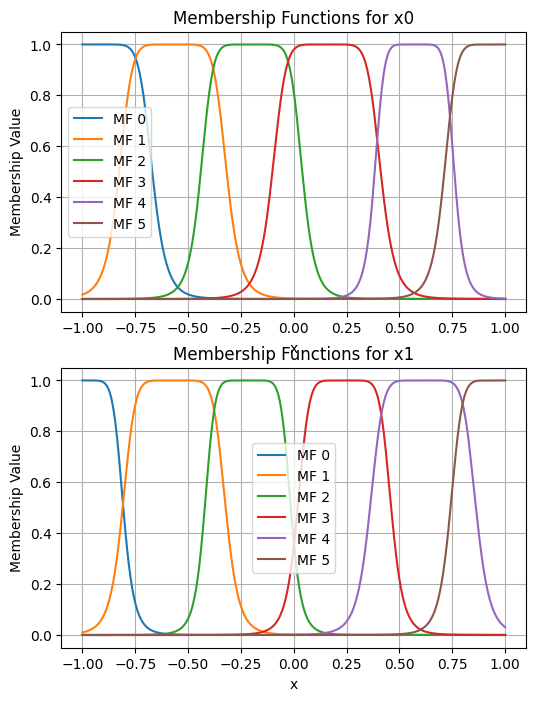

In [17]:
model.plot_premises(group_by_dim=True)

In [18]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.262382,3.997858,-0.931856,0.201341,3.915571,-1.007955
MF 1,0.254399,3.906923,-0.571977,0.243863,3.985554,-0.565936
MF 2,0.239928,4.021641,-0.199754,0.203512,4.098755,-0.217629
MF 3,0.256111,3.864515,0.155291,0.221277,3.930161,0.239628
MF 4,0.188378,3.989242,0.571398,0.250640,3.933216,0.611502
MF 5,0.241007,3.997354,0.953571,0.227961,3.977802,0.969638


In [19]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.1548120379447937
RMSE: 0.3934616148471832
MAE: 0.3145220875740051
R2: 0.9564657211303711
MAPE: 150.9114532470703


In [20]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.46364086866378784
RMSE: 0.6809117794036865
MAE: 0.541374146938324
R2: 0.8674983978271484
MAPE: 2.042556047439575


In [21]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.262382,3.997858,-0.931856,0.201341,3.915571,-1.007955
MF 1,0.254399,3.906923,-0.571977,0.243863,3.985554,-0.565936
MF 2,0.239928,4.021641,-0.199754,0.203512,4.098755,-0.217629
MF 3,0.256111,3.864515,0.155291,0.221277,3.930161,0.239628
MF 4,0.188378,3.989242,0.571398,0.250640,3.933216,0.611502
MF 5,0.241007,3.997354,0.953571,0.227961,3.977802,0.969638


In [22]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,5.085128,-16.681349,-11.182288
rule 2,19.345768,-2.320521,17.633341
rule 3,-16.350983,2.458327,-14.987665
rule 4,3.032744,-0.579628,2.506815
rule 5,-4.408062,-9.872692,1.443139
rule 6,-28.040236,-21.435770,-6.794017
rule 7,4.605910,-6.011995,-2.329767
rule 8,23.278727,5.414955,16.243937
rule 9,-14.986259,-0.628802,-9.769645
rule 10,-2.709260,11.959860,-5.561396
